In [12]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import joblib

In [13]:
df = pd.read_csv(r'C:\Python\analytics\titanic.csv')

In [14]:

X = df.drop("survived", axis=1)
y = df["survived"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])



X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (712, 10)
Testing shape: (179, 10)


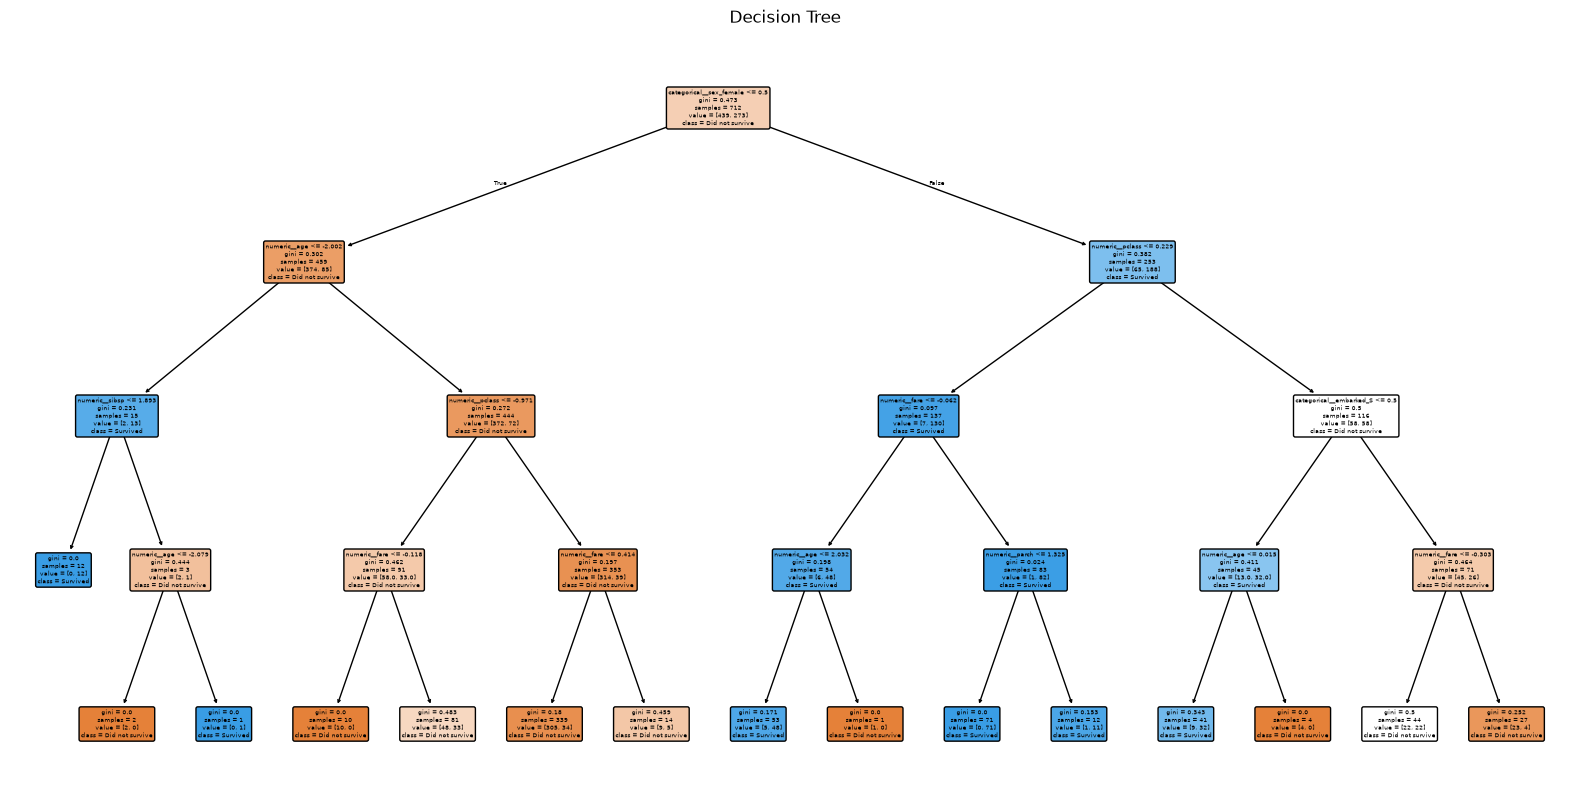

In [15]:

logistic = LogisticRegression(max_iter=1000)

logistic.fit(X_train_processed, y_train)

logistic_pred = logistic.predict(X_test_processed)



tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

tree.fit(X_train_processed, y_train)

tree_pred = tree.predict(X_test_processed)



forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train_processed, y_train)

forest_pred = forest.predict(X_test_processed)


feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree")
plt.show()

Model Comparison
                 Model   TN  FP  FN  TP  Accuracy  Precision  Recall  \
0  Logistic Regression   98  12  23  46     0.804      0.793   0.667   
1        Decision Tree  104   6  32  37     0.788      0.860   0.536   
2        Random Forest   98  12  21  48     0.816      0.800   0.696   

   F1 Score    AUC  
0     0.724  0.844  
1     0.661  0.815  
2     0.744  0.827  


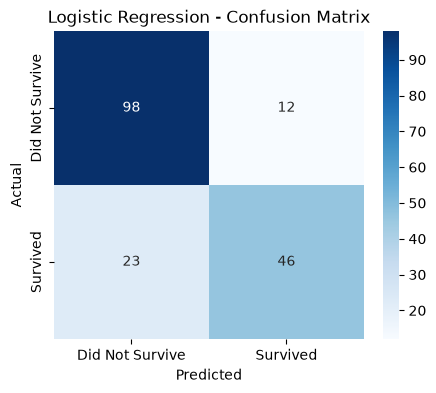

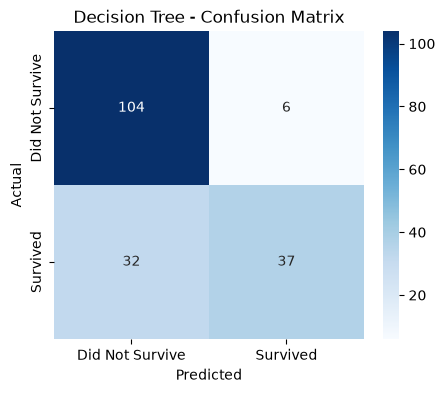

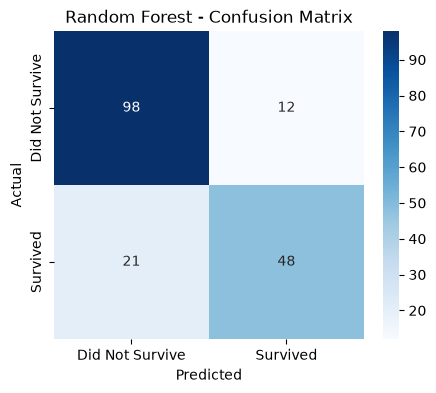

In [16]:

models = {
    "Logistic Regression": logistic,
    "Decision Tree": tree,
    "Random Forest": forest
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })


results_df = pd.DataFrame(results)

print("Model Comparison")
print(results_df.round(3))


for name, model in models.items():

    y_pred = model.predict(X_test_processed)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"]
    )

    plt.title(name + " - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [17]:

print("Class counts:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))


baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_processed, y_train)

baseline_pred = baseline_model.predict(X_test_processed)

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train_processed, y_train)

balanced_pred = balanced_model.predict(X_test_processed)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nTraining class counts after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)


results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, smote_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, smote_pred)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, smote_pred)
    ]
})

print("\nImbalance Handling Comparison:")
print(results.round(3))

Class counts:
survived
0    549
1    342
Name: count, dtype: int64

Class percentages:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Training class counts after SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

Imbalance Handling Comparison:
                  Method  Precision  Recall  F1 Score
0               Baseline      0.793   0.667     0.724
1  Class Weight Balanced      0.730   0.783     0.755
2                  SMOTE      0.740   0.783     0.761


In [18]:

rf = RandomForestClassifier(
    oob_score=True,
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)


best_rf = RandomForestClassifier(
    n_estimators=grid_search.best_params_["n_estimators"],
    max_depth=grid_search.best_params_["max_depth"],
    max_features=grid_search.best_params_["max_features"],
    oob_score=True,
    random_state=42
)

best_rf.fit(X_train_processed, y_train)

print("\nOOB Score:")
print(best_rf.oob_score_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}

Best Cross-Validation F1 Score:
0.7458456231855529

OOB Score:
0.8202247191011236


Linear Regression Results
-------------------------
MAE: 0.305
RMSE: 0.388
R²: 0.363
Adjusted R²: 0.325


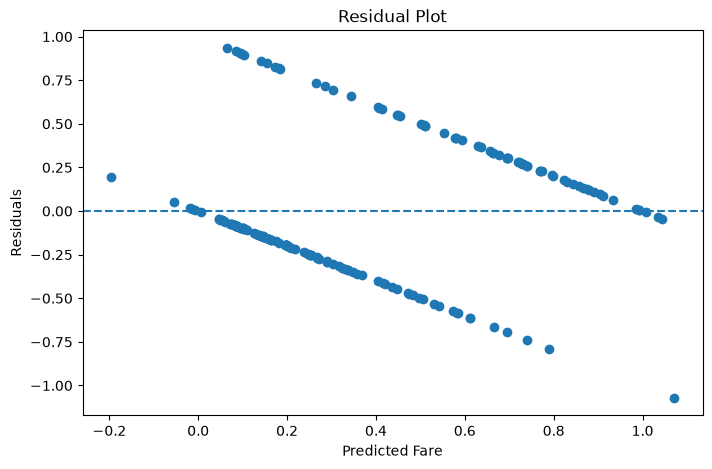

In [19]:

linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

y_pred = linear_model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test_processed.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Linear Regression Results")
print("-------------------------")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
print("Adjusted R²:", round(adjusted_r2, 3))


residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [20]:

classification_results = results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].copy()

regression_results = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
})


classification_results["MAE"] = np.nan
classification_results["RMSE"] = np.nan
classification_results["R²"] = np.nan
classification_results["Adjusted R²"] = np.nan


regression_row = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Accuracy": [np.nan],
    "Precision": [np.nan],
    "Recall": [np.nan],
    "F1 Score": [np.nan],
    "AUC": [np.nan],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
})

model_comparison = pd.concat(
    [classification_results, regression_row],
    ignore_index=True
)

print("MODEL COMPARISON")
print(model_comparison.round(3))

MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score    AUC    MAE  \
0  Logistic Regression     0.804      0.793   0.667     0.724  0.844    NaN   
1        Decision Tree     0.788      0.860   0.536     0.661  0.815    NaN   
2        Random Forest     0.816      0.800   0.696     0.744  0.827    NaN   
3    Linear Regression       NaN        NaN     NaN       NaN    NaN  0.305   

    RMSE     R²  Adjusted R²  
0    NaN    NaN          NaN  
1    NaN    NaN          NaN  
2    NaN    NaN          NaN  
3  0.388  0.363        0.325  


In [21]:

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


full_pipeline.fit(X_train, y_train)


joblib.dump(full_pipeline, "titanic_random_forest_pipeline.joblib")

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [22]:


loaded_pipeline = joblib.load("titanic_random_forest_pipeline.joblib")

predictions = loaded_pipeline.predict(X_test)

print("Predictions:")
print(predictions[:10])

print("Actual values:")
print(y_test.iloc[:10].values)

Predictions:
[0 0 0 0 1 0 1 1 0 0]
Actual values:
[0 0 1 0 1 1 1 0 0 0]
